In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from src.data_loader import load_data
train, features, stores = load_data()

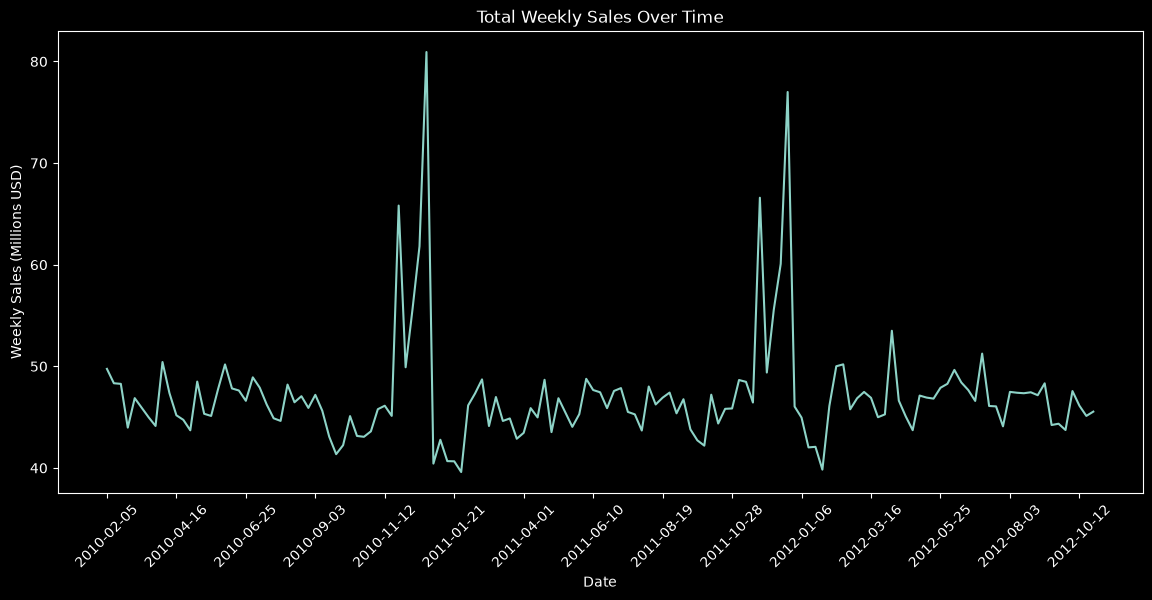

In [9]:
#1. Total sales over time
weekly_sales = train.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(14,6))
weekly_sales = weekly_sales / 1e6
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xticks(weekly_sales.index[::10], rotation=45)
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Millions USD)")
plt.show()

From the graph above, we can see a sharp spike in weekly sales every November. This also coincides with the biggest sales season of the year (Black Friday). The level of volatility is not excessively high in other seasons.
Có xu hướng tăng/giảm không?
Có spike vào dịp nào không?
Có pattern theo năm không?

In [12]:
#2. Holiday Impact
holiday_sales = train.groupby('IsHoliday')['Weekly_Sales'].mean()
print(holiday_sales)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


On average, holiday sales are approximately 7% higher than non-holiday sales.

Store
20    301.397792
4     299.543953
14    288.999911
13    286.517704
2     275.382441
10    271.617714
27    253.855917
6     223.756131
1     222.402809
39    207.445542
19    206.634862
31    199.613905
23    198.750618
24    194.016021
11    193.962787
28    189.263681
41    181.341935
32    166.819246
18    155.114734
22    147.075649
12    144.287230
26    143.416394
34    138.249763
40    137.870310
35    131.520672
8     129.951181
17    127.782139
45    112.395341
21    108.117879
25    101.061179
43     90.565435
15     89.133684
7      81.598275
42     79.565752
9      77.789219
29     77.141554
16     74.252425
37     74.202740
30     62.716885
3      57.586735
38     55.159626
36     53.412215
5      45.475689
44     43.293088
33     37.160222
Name: Weekly_Sales, dtype: float64


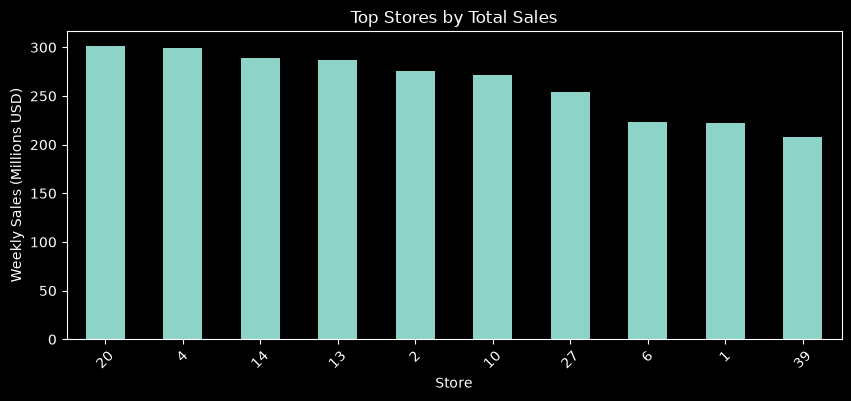

In [17]:
#3. Store Performance
store_sales = train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales = store_sales/1e6
print(store_sales)
store_sales.head(10).plot(kind='bar',figsize=(10,4))
plt.title("Top Stores by Total Sales")
plt.xlabel('Store')
plt.ylabel('Weekly Sales (Millions USD)')
plt.xticks(rotation=45)
plt.show()

Store nào dominate?
Có outlier store không?
Có imbalance không?